Introduction

We are using an Instacart dataset from kaggle to predict whether a user will reorder a previously ordered products in their next purchase. Instacart is an app similar to amazon that allows users to purchase groceries. As the dataset was originally meant for competition, in the orders table eval set = test does not have another table called order_products_test to tell us if a product was reordered. In this project we will

    1. Synthetically create our our synthetic test dataset
    2. Split our data into train and validate sets for validattion
    3. Feature Engineering
    4. Build and train a model
    5. Determine the most important features


In [1]:

import load_data
import feature_engineering
import numpy as np
import pandas as pd
import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, classification_report, f1_score
from sklearn.metrics import f1_score, classification_report, make_scorer
import gc # Garbage Collector to manually free up RAM
import train_model
from sklearn.model_selection import RandomizedSearchCV

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)

# import all the datasets
# 1. Orders
# | Column                   | Meaning                    |
# | ------------------------ | -------------------------- |
# | `order_id`               | Unique order identifier    |
# | `user_id`                | Customer identifier        |
# | `eval_set`               | `prior` / `train` / `test` |
# | `order_number`           | Order sequence per user    |
# | `order_dow`              | Day of week (0–6)          |
# | `order_hour_of_day`      | Hour order was placed      |
# | `days_since_prior_order` | Gap since last order       |
#
# 2. Order products prior
# | Column              | Meaning                              |
# | ------------------- | ------------------------------------ |
# | `order_id`          | Which order                          |
# | `product_id`        | Which product                        |
# | `add_to_cart_order` | Sequence added to cart               |
# | `reordered`         | 1 if user bought this product before |
#
# 3. Order products train
# | Column              | Meaning                              |
# | ------------------- | ------------------------------------ |
# | `order_id`          | Which order                          |
# | `product_id`        | Which product                        |
# | `add_to_cart_order` | Sequence added to cart               |
# | `reordered`         | 1 if user bought this product before |
#
# 4. Products
# | Column          | Meaning             |
# | --------------- | ------------------- |
# | `product_id`    | Product key         |
# | `product_name`  | Product description |
# | `aisle_id`      | Sub-category        |
# | `department_id` | High-level category |
#
# 5. Aisles
# | Column     | Meaning    |
# | ---------- | ---------- |
# | `aisle_id` | Join key   |
# | `aisle`    | Aisle name |
#
#6. Departments
# | Column          | Meaning         |
# | --------------- | --------------- |
# | `department_id` | Join key        |
# | `department`    | Department name |

orders, order_products_prior, order_products_train, products, aisles, departments = load_data.get_data()

orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [2]:
orders['eval_set'].value_counts()

eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

The table below shows how the prior, train and test eval sets were split. The test eval set does not tell us which products were re-ordered as it was hidden for the competition. 

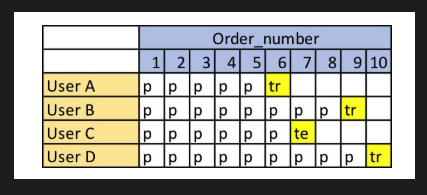

<span style="font-size:20px;">Preoprocessing</span>

In this project, we are utilizing the Instacart dataset from Kaggle. In the original competition, the eval_set = 'test' was reserved for hidden evaluation. To validate our model's performance locally, we will synthetically generate a custom 'test' set by isolating the final known order for each user in the "test" category. To do so, we take the latest/most recent ordeer from the eval_set='prior' for the test users.

<span style="font-size:12px;">
    <b>
    1. Synthetically create our own test orders <br>
    </b>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;1.1 From the orders table, get the test orders and obtain the unique users from the test orders<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;1.2 Obtain the prior orders from the orders table for the specific test users<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;1.3 Get the max (most recent) prior order and update the 'eval_set' to 'test_synthetic'<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;1.4 Remove the 'test_synthetic' orders from 'order_products_prior' to create a order_products_test subset which will be used as a y to validate <br><br>
</span>

<span style="font-size:12px;">
    <b>
    2. Split our train data into train and validate<br>
    </b>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.1 Obtain the validate orders from the train orders and set the 'eval_set' to 'validate'<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.2 Take the validate orders from order_products_train to create order_products_validate<br>
    
</span>




In [3]:
#1 Obtain test users

test_users = orders[orders['eval_set']=='test']['user_id'].copy()
train_users = orders[orders['eval_set']=='train']['user_id'].copy()


In [4]:
#1.2 Obtain the prior orders for the test users

test_users_prior_orders = orders[(orders['eval_set']=='prior') & (orders['user_id'].isin(test_users))].copy()
test_users_prior_orders[test_users_prior_orders['user_id']==15].tail()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
147,1911383,15,prior,18,2,11,7.0
148,2345592,15,prior,19,5,11,3.0
149,2994589,15,prior,20,1,13,10.0
150,2715276,15,prior,21,1,9,7.0
151,487368,15,prior,22,1,10,14.0


In [5]:
#1.3 Obtain the most recent prior order for the test user and update eval set to 'test_synthetic'

test_user_most_recent_order_number = test_users_prior_orders.groupby(['user_id'])['order_number'].transform('max')
synthetic_test_df = test_users_prior_orders[test_users_prior_orders['order_number']==test_user_most_recent_order_number]

synthetic_test_order_ids = synthetic_test_df['order_id'].copy()
orders.loc[(orders['order_id'].isin(synthetic_test_order_ids)), 'eval_set' ] = 'test_synthetic'

In [6]:
orders['eval_set'].value_counts()

eval_set
prior             3139874
train              131209
test_synthetic      75000
test                75000
Name: count, dtype: int64

In [7]:
#1.4 Removing the 'test_synthetic' orders from 'order_products_prior'

order_products_test_synthetic = order_products_prior[order_products_prior['order_id'].isin(synthetic_test_order_ids)].copy()
order_products_prior = order_products_prior[~order_products_prior['order_id'].isin(synthetic_test_order_ids)].copy()


In [8]:
#2.1 Train, Validate split our train orders data

from sklearn.model_selection import train_test_split

y_train_users, y_validate_users = train_test_split(train_users, test_size=0.2, random_state=123)

orders.loc[(orders['user_id'].isin(y_validate_users)) & (orders['eval_set']=='train'), 'eval_set'] = 'validate'

validate_orders = orders[(orders['eval_set']=='validate')]['order_id']
order_products_validate = order_products_train[order_products_train['order_id'].isin(validate_orders)]
order_products_train = order_products_train[~(order_products_train['order_id'].isin(validate_orders))]



Feature Engineering

1. User features
2. Product features
3. User-Product features
4. Aisle Features
5. Department Features

In [9]:
#Merging to get product data

prior_orders = orders[orders['eval_set']=='prior'].copy()

op = prior_orders.merge(
    order_products_prior,
    how='left',
    on='order_id'
)

In [10]:
op.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered
0,2539329,1,prior,1,2,8,NaN,196,1,0
1,2539329,1,prior,1,2,8,NaN,14084,2,0
2,2539329,1,prior,1,2,8,NaN,12427,3,0
3,2539329,1,prior,1,2,8,NaN,26088,4,0
4,2539329,1,prior,1,2,8,NaN,26405,5,0


In [11]:
user_features = feature_engineering.get_user_features(op)

In [12]:
product_features = feature_engineering.get_product_features(op)

In [13]:
user_product_features = feature_engineering.get_user_product_features(op)

In [14]:
#Creating aisle and department features

opad = op.merge(
    products[['product_id', 'aisle_id', 'department_id']], 
    how='left',
    on='product_id'
)

opad=opad[['user_id', 'order_id', 'product_id', 'reordered', 'aisle_id', 'department_id']]
opad.head()

,user_id,order_id,product_id,reordered,aisle_id,department_id
0,1,2539329,196,0,77,7
1,1,2539329,14084,0,91,16
2,1,2539329,12427,0,23,19
3,1,2539329,26088,0,23,19
4,1,2539329,26405,0,54,17


In [15]:
aisle_and_department_features = feature_engineering.get_aisle_department_features(opad)

In [16]:
#4 Merge all the fetures together from the prior data

df = user_product_features.merge(
    user_features,
    how='left',
    on='user_id'
)

df = df.merge(
    product_features,
    how='left',
    on='product_id'
)

df = df.merge(
    aisle_and_department_features,
    how='left',
    on=['user_id', 'product_id']
)

df.head()

,user_id,product_id,up_total_purchases,up_first_order,up_last_order,up_reorder_ratio,up_avg_days_between_purchase,up_avg_add_to_cart_order,up_consecutive_streak,u_total_orders,u_reorder_ratio,u_unique_products,u_dow_mode,u_hour_of_day_mode,u_avg_basket_size,u_avg_days_since_prior_order,u_avg_basket_reorder_rate,p_total_purchases,p_reorder_ratio,aisle_id,department_id,a_reorder_ratio,a_total_orders,ua_reorder_ratio,ua_total_orders,d_reorder_ratio,d_total_orders,ud_reorder_ratio,ud_total_orders
0,1,196,10,1,10,0.900000,19.555556,1.400000,10.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,34952,0.776150,77,7,0.638676,348349,0.846154,13,0.653531,2625872,0.846154,13
1,1,10258,9,2,10,0.888889,19.555556,3.333333,9.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,1899,0.713007,117,19,0.519297,299547,0.888889,9,0.574232,2819848,0.818182,22
2,1,10326,1,5,5,0.000000,28.000000,5.000000,0.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,5301,0.651009,24,4,0.717928,3557919,0.200000,5,0.649857,9251194,0.200000,5
3,1,12427,10,1,10,0.900000,19.555556,3.300000,10.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,6334,0.741238,23,19,0.591772,159570,0.833333,12,0.574232,2819848,0.818182,22
4,1,13032,3,2,10,0.222222,21.666667,6.333333,1.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,3663,0.658750,121,14,0.571751,368426,0.666667,3,0.561251,692737,0.666667,3


In [17]:
#Now that we have all the features, we want to merge with the most recent train, validate or test order to obtain the y varaible

future_orders = orders[orders['eval_set'].isin(['train', 'validate', 'test_synthetic'])].copy()
future_orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
10,1187899,1,train,11,4,8,14.0
25,1492625,2,train,15,1,11,30.0
37,1402502,3,test_synthetic,12,1,15,15.0
43,2557754,4,test_synthetic,5,5,13,0.0
49,2196797,5,validate,5,0,11,6.0


In [18]:
df = df.merge(
    future_orders,
    how='left',
    on='user_id'
)

In [19]:
df.head()

,user_id,product_id,up_total_purchases,up_first_order,up_last_order,up_reorder_ratio,up_avg_days_between_purchase,up_avg_add_to_cart_order,up_consecutive_streak,u_total_orders,u_reorder_ratio,u_unique_products,u_dow_mode,u_hour_of_day_mode,u_avg_basket_size,u_avg_days_since_prior_order,u_avg_basket_reorder_rate,p_total_purchases,p_reorder_ratio,aisle_id,department_id,a_reorder_ratio,a_total_orders,ua_reorder_ratio,ua_total_orders,d_reorder_ratio,d_total_orders,ud_reorder_ratio,ud_total_orders,order_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1,196,10,1,10,0.900000,19.555556,1.400000,10.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,34952,0.776150,77,7,0.638676,348349,0.846154,13,0.653531,2625872,0.846154,13,1187899,train,11,4,8,14.0
1,1,10258,9,2,10,0.888889,19.555556,3.333333,9.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,1899,0.713007,117,19,0.519297,299547,0.888889,9,0.574232,2819848,0.818182,22,1187899,train,11,4,8,14.0
2,1,10326,1,5,5,0.000000,28.000000,5.000000,0.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,5301,0.651009,24,4,0.717928,3557919,0.200000,5,0.649857,9251194,0.200000,5,1187899,train,11,4,8,14.0
3,1,12427,10,1,10,0.900000,19.555556,3.300000,10.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,6334,0.741238,23,19,0.591772,159570,0.833333,12,0.574232,2819848,0.818182,22,1187899,train,11,4,8,14.0
4,1,13032,3,2,10,0.222222,21.666667,6.333333,1.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,3663,0.658750,121,14,0.571751,368426,0.666667,3,0.561251,692737,0.666667,3,1187899,train,11,4,8,14.0


In [20]:
model_train_data = feature_engineering.get_split_data(df, 'train', order_products_train)
model_validate_data = feature_engineering.get_split_data(df, 'validate', order_products_validate)
model_test_synthetic_data = feature_engineering.get_split_data(df, 'test_synthetic', order_products_test_synthetic)


In [21]:
model_train_data.head()

,user_id,product_id,up_total_purchases,up_first_order,up_last_order,up_reorder_ratio,up_avg_days_between_purchase,up_avg_add_to_cart_order,up_consecutive_streak,u_total_orders,u_reorder_ratio,u_unique_products,u_dow_mode,u_hour_of_day_mode,u_avg_basket_size,u_avg_days_since_prior_order,u_avg_basket_reorder_rate,p_total_purchases,p_reorder_ratio,aisle_id,department_id,a_reorder_ratio,a_total_orders,ua_reorder_ratio,ua_total_orders,d_reorder_ratio,d_total_orders,ud_reorder_ratio,ud_total_orders,order_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered
0,1,196,10,1,10,0.900000,19.555556,1.400000,10.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,34952,0.776150,77,7,0.638676,348349,0.846154,13,0.653531,2625872,0.846154,13,1187899,train,11,4,8,14.0,1.0,1.0
1,1,10258,9,2,10,0.888889,19.555556,3.333333,9.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,1899,0.713007,117,19,0.519297,299547,0.888889,9,0.574232,2819848,0.818182,22,1187899,train,11,4,8,14.0,6.0,1.0
2,1,10326,1,5,5,0.000000,28.000000,5.000000,0.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,5301,0.651009,24,4,0.717928,3557919,0.200000,5,0.649857,9251194,0.200000,5,1187899,train,11,4,8,14.0,NaN,0.0
3,1,12427,10,1,10,0.900000,19.555556,3.300000,10.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,6334,0.741238,23,19,0.591772,159570,0.833333,12,0.574232,2819848,0.818182,22,1187899,train,11,4,8,14.0,NaN,0.0
4,1,13032,3,2,10,0.222222,21.666667,6.333333,1.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,3663,0.658750,121,14,0.571751,368426,0.666667,3,0.561251,692737,0.666667,3,1187899,train,11,4,8,14.0,7.0,1.0


In [22]:
cols_to_drop = ['order_id', 'eval_set', 'add_to_cart_order', 'reordered']

X_train = model_train_data.drop(columns=cols_to_drop)
y_train = model_train_data['reordered']

X_train = X_train.astype('float32') #downcast to save memory

X_val = model_validate_data.drop(columns=cols_to_drop)
y_val = model_validate_data['reordered']

train_ratio = (y_train==0).sum() / (y_train==1).sum()
val_ratio = (y_val==0).sum() / (y_val==1).sum()

print(f"The train dataset is unbalanced on a scale from 1: {train_ratio:.3f}")
print(f"The validate dataset is unbalanced on a scale from 1: {val_ratio:.3f}")

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 6,
    'learning_rate': 0.1,
    'tree_method': 'hist', #groups the values into buckets so its faster to split into branches and leaves
    'scale_pos_weight': int(train_ratio)-1, #puts more weight on the reorders on a scale of 1 : train_ratio
    'seed':123
}

xgb_train_dmatrix = xgb.DMatrix(X_train, y_train)
xgb_model = xgb.train(xgb_params, xgb_train_dmatrix, num_boost_round=100)

xgb_train_y_pred = xgb_model.predict(xgb_train_dmatrix)
xgb_train_pr_auc = average_precision_score(y_train, xgb_train_y_pred)
print(f"Train PR AUC: {xgb_train_pr_auc:.3f}")


xgb_val_dmatrix = xgb.DMatrix(X_val, y_val)
xgb_val_y_pred = xgb_model.predict(xgb_val_dmatrix)
xgb_val_pr_auc = average_precision_score(y_val, xgb_val_y_pred)
print(f"Validation PR AUC: {xgb_val_pr_auc:.3f}")



The train dataset is unbalanced on a scale from 1: 9.226
The validate dataset is unbalanced on a scale from 1: 9.219
Train PR AUC: 0.427
Validation PR AUC: 0.421


In [23]:
# We want to find the best threshold based on the F1 score
# Base it off the validation set to prevent over fitting
threshold = np.arange(0.6, 0.925, 0.025)

xgb_validate_best_threshold = train_model.threshold_optimized_f1(y_val, xgb_val_y_pred, threshold)


print(f"The best threshold for XGBoost validation data was: {xgb_validate_best_threshold:.2f}")
xgb_val_report = classification_report(y_val, (xgb_val_y_pred > xgb_validate_best_threshold).astype(np.int8))
print(xgb_val_report)

The best threshold for XGBoost validation data was: 0.70
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93   1531587
         1.0       0.41      0.48      0.44    166131

    accuracy                           0.88   1697718
   macro avg       0.67      0.70      0.69   1697718
weighted avg       0.89      0.88      0.88   1697718



In [24]:
lgbm_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.1,
    'scale_pos_weight': int(train_ratio)-1,
    'random_state': 123,
    'n_jobs': -1,
    'verbosity': -1 # Keeps the output clean
}


lgbm_dataset = lgb.Dataset(X_train, y_train)
lgbm_model = lgb.train(lgbm_params, lgbm_dataset, num_boost_round=100)

lgbm_train_y_pred = lgbm_model.predict(X_train)
lgbm_train_pr_auc = average_precision_score(y_train, lgbm_train_y_pred)

lgbm_val_y_pred = lgbm_model.predict(X_val)
lgbm_val_pr_auc = average_precision_score(y_val, lgbm_val_y_pred)


print(f"Train PR AUC: {lgbm_train_pr_auc:.3f}")
print(f"Validation PR AUC: {lgbm_train_pr_auc:.3f}")


Train PR AUC: 0.424
Validation PR AUC: 0.424


In [25]:

lgbm_validate_best_threshold = train_model.threshold_optimized_f1(y_val, lgbm_val_y_pred, threshold)

print(f"The best threshold for LightGBM validation data was: {lgbm_validate_best_threshold:.2f}")
lgbm_val_report = classification_report(y_val, (lgbm_val_y_pred > lgbm_validate_best_threshold).astype(np.int8))
print(lgbm_val_report)

The best threshold for LightGBM validation data was: 0.70
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93   1531587
         1.0       0.40      0.48      0.44    166131

    accuracy                           0.88   1697718
   macro avg       0.67      0.70      0.69   1697718
weighted avg       0.89      0.88      0.88   1697718



In [26]:
train_pool = Pool(X_train, y_train)
val_pool = Pool(X_val, y_val)

cat_params = {
    'iterations': 100,
    'learning_rate': 0.1,
    'objective': 'Logloss',
    'eval_metric': 'PRAUC',
    'scale_pos_weight': int(train_ratio) - 1,
    'random_seed': 123,
    'thread_count': -1,
    'verbose': False,
    'allow_writing_files': False
}

cat_model = CatBoostClassifier(**cat_params)
cat_model.fit(train_pool)

cat_train_y_pred = cat_model.predict(X_train, prediction_type='Probability')[:, 1]
cat_val_y_pred = cat_model.predict(X_val, prediction_type='Probability')[:, 1]

cat_train_pr_auc = average_precision_score(y_train, cat_train_y_pred)
cat_val_pr_auc = average_precision_score(y_val, cat_val_y_pred)

print(f"CatBoost Train PR AUC: {cat_train_pr_auc:.3f}")
print(f"CatBoost Validation PR AUC: {cat_val_pr_auc:.3f}")

CatBoost Train PR AUC: 0.415
CatBoost Validation PR AUC: 0.413


In [27]:
cat_validate_best_threshold = train_model.threshold_optimized_f1(y_val, cat_val_y_pred, threshold)

print(f"The best threshold for CatBoost validation data was: {cat_validate_best_threshold:.2f}")
cat_val_report_final = classification_report(y_val, (cat_val_y_pred > cat_validate_best_threshold).astype(np.int8))
print(cat_val_report_final)

The best threshold for CatBoost validation data was: 0.68
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93   1531587
         1.0       0.39      0.49      0.43    166131

    accuracy                           0.87   1697718
   macro avg       0.67      0.70      0.68   1697718
weighted avg       0.89      0.87      0.88   1697718



In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

lr_params = {
    'max_iter': 1000,
    'C': 1.0, 
    'class_weight': {0: 1, 1: int(train_ratio) - 1},
    'random_state': 123
}

lr_model = LogisticRegression(**lr_params)
lr_model.fit(X_train_scaled, y_train)

# [:, 1] gets the probability for the 'reorder' class
lr_train_y_pred = lr_model.predict_proba(X_train_scaled)[:, 1]
lr_train_pr_auc = average_precision_score(y_train, lr_train_y_pred)
print(f"Logistic Regression Train PR AUC: {lr_train_pr_auc:.3f}")

lr_val_y_pred = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_val_pr_auc = average_precision_score(y_val, lr_val_y_pred)
print(f"Logistic Regression Validation PR AUC: {lr_val_pr_auc:.3f}")

Logistic Regression Train PR AUC: 0.401
Logistic Regression Validation PR AUC: 0.400


In [29]:
lr_validate_best_threshold = train_model.threshold_optimized_f1(y_val, lr_val_y_pred, threshold)

print(f"The best threshold for Logistic Regression validation data was: {lr_validate_best_threshold:.2f}")
print(classification_report(y_val, (lr_val_y_pred > lr_validate_best_threshold).astype(np.int8)))

The best threshold for Logistic Regression validation data was: 0.65
              precision    recall  f1-score   support

         0.0       0.94      0.91      0.93   1531587
         1.0       0.37      0.49      0.42    166131

    accuracy                           0.87   1697718
   macro avg       0.66      0.70      0.67   1697718
weighted avg       0.89      0.87      0.88   1697718



In [30]:
xgb_val_f1 = f1_score(y_val, (xgb_val_y_pred > xgb_validate_best_threshold).astype(np.int8))
lgbm_val_f1 = f1_score(y_val, (lgbm_val_y_pred > lgbm_validate_best_threshold).astype(np.int8))
cat_val_f1 = f1_score(y_val, (cat_val_y_pred > cat_validate_best_threshold).astype(np.int8))
lr_val_f1 = f1_score(y_val, (lr_val_y_pred > lr_validate_best_threshold).astype(np.int8))


print("Summary of our 4 models\n")
print(f"""XGBoost:
Train PR AUC: {xgb_train_pr_auc:.3f}
Validation PR AUC: {xgb_val_pr_auc:.3f}
Validation F1 score: {xgb_val_f1:.3f}

LightGBM:
Train PR AUC: {lgbm_train_pr_auc:.3f}
Validation PR AUC: {lgbm_val_pr_auc:.3f}
Validation F1 score: {lgbm_val_f1:.3f}

CatBoost:
Train PR AUC: {cat_train_pr_auc:.3f}
Validation PR AUC: {cat_val_pr_auc:.3f}
Validation F1 score: {cat_val_f1:.3f}

Logistic Regression:
Train PR AUC: {lr_train_pr_auc:.3f}
Validation PR AUC: {lr_val_pr_auc:.3f}
Validation F1 score: {lr_val_f1:.3f}

""")

Summary of our 4 models

XGBoost:
Train PR AUC: 0.427
Validation PR AUC: 0.421
Validation F1 score: 0.438

LightGBM:
Train PR AUC: 0.424
Validation PR AUC: 0.420
Validation F1 score: 0.439

CatBoost:
Train PR AUC: 0.415
Validation PR AUC: 0.413
Validation F1 score: 0.434

Logistic Regression:
Train PR AUC: 0.401
Validation PR AUC: 0.400
Validation F1 score: 0.422




In [ ]:
xgb_clf = XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    eval_metric='logloss',
    n_estimators=100,
    random_state=123
)

xgb_params = {
    'max_depth': [6,8],
    'learning_rate': [0.1, 0.2],
    'scale_pos_weight': [int(train_ratio)-2, int(train_ratio)-1], #puts more weight on the reorders on a scale of 1 : train_ratio
}

# Ensure you are referencing the function correctly from your train_model file
xgb_threshold_score = make_scorer(
    train_model.custom_f1_threshold, 
    threshold=xgb_validate_best_threshold      # This will be passed to your function's 'threshold' argument
)

xgb_random_search = RandomizedSearchCV(
    estimator= xgb_clf,
    param_distributions=xgb_params,
    scoring=xgb_threshold_score,
    cv=5, #Datset is split into 5 for cross valdiation (80% train, 20% test)
    n_iter=3, #3 random search picks from our params
    n_jobs=-1,
    random_state=123
)

xgb_random_search.fit(X_train, y_train)
# To see your results:
print(f"XGB Best Score: {xgb_random_search.best_score_}")
print(f"XGB Best Params: {xgb_random_search.best_params_}")

gc.collect()

Best Score: 0.3970811509109422
Best Params: {'scale_pos_weight': 7, 'max_depth': 6, 'learning_rate': 0.1}


63

In [ ]:
lgbm_clf = LGBMClassifier(    
    objective='binary',
    metric= 'binary_logloss',
    boosting_type='gbdt',
    n_estimators=100,
    random_state=123,
    verbosity = -1
)

lgbm_params = {
    'num_leaves': [31, 63],
    'learning_rate': [0.1, 0.2],
    'scale_pos_weight': [int(train_ratio)-2, int(train_ratio)-1]
}

lgbm_threshold_score = make_scorer(
    train_model.custom_f1_threshold,
    threshold=lgbm_validate_best_threshold
)

lgbm_random_search = RandomizedSearchCV(
    estimator = lgbm_clf,
    param_distributions=lgbm_params,
    scoring = lgbm_threshold_score,
    cv=5,
    n_iter=3,
    n_jobs=-1,
    random_state =123
)

lgbm_random_search.fit(X_train, y_train)
# To see your results:
print(f"LGBM Best Score: {lgbm_random_search.best_score_}")
print(f"LGBM Best Params: {lgbm_random_search.best_params_}")
gc.collect()

Best Score: 0.3945384585843096
Best Params: {'scale_pos_weight': 7, 'num_leaves': 31, 'learning_rate': 0.1}


66

In [ ]:
cat_clf = CatBoostClassifier(    
    objective='Logloss',
    iterations = 100,
    random_seed = 123,
    thread_count = -1,
    verbose = False,
    allow_writing_files = False
)

cat_params = {
    'depth': [6, 8],
    'learning_rate': [0.1, 0.2],
    'scale_pos_weight': [int(train_ratio)-2, int(train_ratio)-1]
}

cat_threshold_score = make_scorer(
    train_model.custom_f1_threshold,
    threshold=cat_validate_best_threshold
)

cat_random_search = RandomizedSearchCV(
    estimator = cat_clf,
    param_distributions=cat_params,
    scoring = cat_threshold_score,
    cv=5,
    n_iter=3,
    n_jobs=1,
    random_state =123
)

cat_random_search.fit(X_train, y_train)
# To see your results:
print(f"CatBoost Best Score: {cat_random_search.best_score_}")
print(f"CatBoost Best Params: {cat_random_search.best_params_}")
gc.collect()

Best Score: 0.40001527935596126
Best Params: {'scale_pos_weight': 7, 'learning_rate': 0.1, 'depth': 6}


23

In [ ]:
lr_clf = LogisticRegression(    
    solver='saga',
    max_iter = 100,
    random_state = 123,
)

lr_params = {
    'max_iter': [500, 1000],
    'C': [1.0, 10.0], 
    'class_weight': [{0: 1, 1: int(train_ratio) - 2}, {0: 1, 1: int(train_ratio) - 1}],
}

lr_threshold_score = make_scorer(
    train_model.custom_f1_threshold,
    threshold=lr_validate_best_threshold
)

lr_random_search = RandomizedSearchCV(
    estimator = lr_clf,
    param_distributions=lr_params,
    scoring = lr_threshold_score,
    cv=5,
    n_iter=3,
    n_jobs=-1,
    random_state =123
)

lr_random_search.fit(X_train_scaled, y_train)
# To see your results:
print(f"Logistic Regression Best Score: {lr_random_search.best_score_}")
print(f"Logistic Regression Best Params: {lr_random_search.best_params_}")
gc.collect()

Best Score: 0.39581793757978223
Best Params: {'max_iter': 500, 'class_weight': {0: 1, 1: 7}, 'C': 1.0}


2937

In [ ]:
#using XGB best params
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 6,
    'learning_rate': 0.1,
    'tree_method': 'hist', 
    'scale_pos_weight': 7, 
    'seed':123
}
xgb_model = xgb.train(xgb_params, xgb_train_dmatrix, num_boost_round=100)
xgb_val_y_pred = xgb_model.predict(xgb_val_dmatrix)
xgb_val_report = classification_report(y_val, (xgb_val_y_pred > xgb_validate_best_threshold).astype(np.int8))
print(xgb_val_report)



              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94   1531587
         1.0       0.43      0.44      0.43    166131

    accuracy                           0.89   1697718
   macro avg       0.68      0.69      0.69   1697718
weighted avg       0.89      0.89      0.89   1697718



In [38]:
#using LightGBM best params
lgbm_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.1,
    'scale_pos_weight': 7,
    'random_state': 123,
    'n_jobs': -1,
    'verbosity': -1 # Keeps the output clean
}

lgbm_model = lgb.train(lgbm_params, lgbm_dataset, num_boost_round=100)
lgbm_val_y_pred = lgbm_model.predict(X_val)
lgbm_val_report = classification_report(y_val, (lgbm_val_y_pred > lgbm_validate_best_threshold).astype(np.int8))
print(lgbm_val_report)

              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94   1531587
         1.0       0.43      0.44      0.44    166131

    accuracy                           0.89   1697718
   macro avg       0.68      0.69      0.69   1697718
weighted avg       0.89      0.89      0.89   1697718



In [39]:
#using CatBoost best params

cat_params = {
    'iterations': 100,
    'learning_rate': 0.1,
    'objective': 'Logloss',
    'eval_metric': 'PRAUC',
    'scale_pos_weight': 7,
    'depth': 6,
    'random_seed': 123,
    'thread_count': -1,
    'verbose': False,
    'allow_writing_files': False
}
cat_model = CatBoostClassifier(**cat_params)
cat_model.fit(train_pool)
cat_val_y_pred = cat_model.predict(X_val, prediction_type='Probability')[:, 1]
cat_val_report_final = classification_report(y_val, (cat_val_y_pred > cat_validate_best_threshold).astype(np.int8))
print(cat_val_report_final)

              precision    recall  f1-score   support

         0.0       0.94      0.93      0.93   1531587
         1.0       0.41      0.45      0.43    166131

    accuracy                           0.88   1697718
   macro avg       0.68      0.69      0.68   1697718
weighted avg       0.89      0.88      0.89   1697718



In [40]:
#using Logistic Regression best params

lr_params = {
    'max_iter': 500,
    'C': 1.0, 
    'class_weight': {0: 1, 1:7},
    'random_state': 123
}

lr_model = LogisticRegression(**lr_params)
lr_model.fit(X_train_scaled, y_train)

lr_val_y_pred = lr_model.predict_proba(X_val_scaled)[:, 1]
print(f"The best threshold for Logistic Regression validation data was: {lr_validate_best_threshold:.2f}")
print(classification_report(y_val, (lr_val_y_pred > lr_validate_best_threshold).astype(np.int8)))

The best threshold for Logistic Regression validation data was: 0.65
              precision    recall  f1-score   support

         0.0       0.94      0.93      0.93   1531587
         1.0       0.40      0.45      0.42    166131

    accuracy                           0.88   1697718
   macro avg       0.67      0.69      0.68   1697718
weighted avg       0.89      0.88      0.88   1697718

